# XGBoost para spec-z — variante com StandardScaler (column-wise)

**Notebook gemeo do [xgb_pca_didatico.ipynb](xgb_pca_didatico.ipynb), com UMA so' diferenca**: a normalizacao do espectro.

| | `xgb_pca_didatico.ipynb` (original) | **este notebook (stdscaler)** |
|---|---|---|
| Normalizacao | `normalize_spectra` (max-abs por linha) | `StandardScaler` (column-wise, por wavelength bin) |
| Fit | aplicado ao dataset todo (nao usa stats do treino) | `fit` so' no train, `transform` em val/test |
| Resultado por espectro | cada galaxia em [-1,+1] | cada bin com mean=0, std=1 no train |
| PCA induzido | covariancia-based | correlacao-based |

**Tudo o resto e identico**: splits estratificados, `N_COMPONENTS`, HPs do XGBoost, plots, metricas.

## Objetivo

Comparar qual normalizacao da' melhor sigma_NMAD no test, com tudo o resto identico (mesmo `SEED` -> mesmas galaxias em train/val/test).

Run anterior (`normalize_spectra`, 300 PCs, MSE): **NMAD = 0.0286**

Este notebook salva em `models/{OBJ}/xgb_pca_stdscaler/` e `results/{OBJ}/xgb_pca_stdscaler/`, sem sobrescrever o original.

## 1. Parametros (papermill)

Permite rodar via:
```
papermill xgb_pca_didatico.ipynb out.ipynb -p OBJECT_TYPE LRG
```

In [2]:
OBJECT_TYPE   = 'LRG'    # 'ELG' | 'LRG' | 'QSO'
SEED          = 42
N_COMPONENTS  = 300       # quantos PCs guardar (alvo: reter >=95% da variancia; ver scree plot)
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15

## 2. Imports e setup

Reuso as mesmas funcoes da CNN:
- `load_spectral_dataset`: le o HDF5 padded
- `normalize_spectra`: max-abs por linha (-> [-1, 1])

Para o XGBoost:
- `xgboost.XGBRegressor`: API do scikit-learn (mais simples que `xgb.train`)
- `sklearn.decomposition.PCA`: faz a reducao de dimensionalidade
- `sklearn.preprocessing.StandardScaler`: z-score nas features finais

In [3]:
import sys, os, time, json, random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
import xgboost as xgb

# walk-up pro project root
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'config.py').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from config import paths_for, RESULTS_DIR, MODELS_DIR
from src.data import load_spectral_dataset, normalize_spectra

# reprodutibilidade
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sns.set_theme(style='whitegrid')

print(f'numpy   : {np.__version__}')
print(f'xgboost : {xgb.__version__}')
print(f'objeto  : {OBJECT_TYPE}')

numpy   : 1.26.4
xgboost : 3.2.0
objeto  : LRG


## 3. Carrega espectros e extrai scalars

**Experimento de normalizacao**: vamos trocar o `normalize_spectra` (max-abs por linha, range [-1,+1]) por **`StandardScaler` column-wise** (cada bin de comprimento de onda vira mean=0, std=1 no train).

**Nova ordem** (anti-leak: o `StandardScaler` precisa de `fit` so' no train):\n1. Carrega bruto\n2. Extrai scalars do bruto\n3. Splits 3-way em `X_orig` (sem normalizar ainda)\n4. `StandardScaler.fit(X_train)` -> aplica em val/test\n\n**Diferenca conceitual**:\n\n| | `normalize_spectra` (antes) | `StandardScaler` (agora) |\n|---|---|---|\n| Direcao | por linha (cada galaxia) | por coluna (cada wavelength bin) |\n| Resultado | cada galaxia em [-1,+1] | cada bin com mean=0, std=1 no train |\n| O que preserva | forma da galaxia | diferencas absolutas entre galaxias num mesmo bin |\n| PCA induzido | covariancia-based | correlacao-based |\n\nOs scalars (log_max, log_median, log_sum, log_p95) continuam — sao 4 numeros de brilho global que entram no XGBoost junto com os PCs.

In [4]:
def extract_scalars(X_orig):
    """4 features de escala por espectro (em log10, do fluxo bruto).
    
    Mesma funcao que a CNN usa.
    """
    X_abs = np.abs(X_orig)
    X_pos = np.where(X_orig > 0, X_orig, np.nan)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        log_max    = np.log10(X_abs.max(axis=1))
        log_median = np.log10(np.nanmedian(X_pos, axis=1))
        log_sum    = np.log10(X_abs.sum(axis=1))
        log_p95    = np.log10(np.nanpercentile(X_pos, 95, axis=1))
    
    scalars = np.stack([log_max, log_median, log_sum, log_p95], axis=1)
    scalars = np.where(np.isfinite(scalars), scalars, -40.0)
    return scalars.astype(np.float32)


paths = paths_for(OBJECT_TYPE)
HDF5 = paths['spectra_h5'].with_name(f'{OBJECT_TYPE}spectra_padded.h5')
print(f'HDF5: {HDF5}')

X_orig, y_all, n_wave = load_spectral_dataset(HDF5)
scalars_all = extract_scalars(X_orig)
X_orig = X_orig.astype(np.float32)   # mantem bruto; normaliza so' apos o split (anti-leak)
y_all = y_all.astype(np.float32)

print(f'\nX_orig      : {X_orig.shape}  (raw, sem normalizar)')
print(f'scalars_all : {scalars_all.shape}')
print(f'y_all       : {y_all.shape}  z em [{y_all.min():.3f}, {y_all.max():.3f}]')
print(f'\nStats do bruto (antes de qualquer normalizacao):')
print(f'  min   = {X_orig.min():.3g}')
print(f'  max   = {X_orig.max():.3g}')
print(f'  mean  = {X_orig.mean():.3g}')
print(f'  std   = {X_orig.std():.3g}')

HDF5: /home/thalita/spec_z_ml/data/processed/LRG/LRGspectra_padded.h5

X_orig      : (130952, 4674)  (raw, sem normalizar)
scalars_all : (130952, 4)
y_all       : (130952,)  z em [0.600, 1.000]

Stats do bruto (antes de qualquer normalizacao):
  min   = -3.59e-15
  max   = 4.77e-15
  mean  = 4.48e-18
  std   = 1.03e-17


## 4. Splits 3-way estratificados por z

Mesma logica da CNN: discretiza z em 20 bins de quantis e preserva a proporcao de cada bin em train/val/test. Evita que o test caia em uma faixa de z muito diferente do train.

**Importante**: tudo (X_spec, scalars, y) e splitado JUNTO — as mesmas amostras vao pra mesmo split.

In [5]:
def make_strat_bins(y, n_splits=2, start_q=20, min_q=2):
    """Bins de z robustos a duplicatas (baixa q se algum bin tiver < n_splits)."""
    q = start_q
    while q >= min_q:
        bins = pd.qcut(y, q=q, labels=False, duplicates='drop')
        counts = pd.Series(bins).value_counts()
        if (counts >= n_splits).all():
            return np.asarray(bins), q
        q -= 1
    raise ValueError('Nao consegui estratificar.')


# Outer split: pool / test
z_bins_all, q_outer = make_strat_bins(y_all)
sss_outer = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
pool_idx, test_idx = next(sss_outer.split(X_orig, z_bins_all))

# Inner split: train / val (dentro do pool)
y_pool = y_all[pool_idx]
z_bins_pool, q_inner = make_strat_bins(y_pool)
sss_inner = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_in_pool, val_in_pool = next(sss_inner.split(np.zeros(len(y_pool)), z_bins_pool))

# Aplica os indices — X_orig ainda BRUTO; padronizacao vem na proxima celula
X_pool  = X_orig[pool_idx]
S_pool  = scalars_all[pool_idx]
X_test  = X_orig[test_idx];      S_test  = scalars_all[test_idx];      y_test  = y_all[test_idx]
X_train = X_pool[train_in_pool]; S_train = S_pool[train_in_pool];     y_train = y_pool[train_in_pool]
X_val   = X_pool[val_in_pool];   S_val   = S_pool[val_in_pool];       y_val   = y_pool[val_in_pool]

print(f'Outer q = {q_outer} bins | Inner q = {q_inner} bins\n')
print(f'Train : n = {len(y_train):>7,}  z_mean = {y_train.mean():.4f}')
print(f'Val   : n = {len(y_val):>7,}  z_mean = {y_val.mean():.4f}')
print(f'Test  : n = {len(y_test):>7,}  z_mean = {y_test.mean():.4f}')
print(f'\n(z_mean parecido nos 3 splits = estratificacao funcionou)')

Outer q = 20 bins | Inner q = 20 bins

Train : n =  94,612  z_mean = 0.7409
Val   : n =  16,697  z_mean = 0.7410
Test  : n =  19,643  z_mean = 0.7410

(z_mean parecido nos 3 splits = estratificacao funcionou)


## 4b. Normalizacao com StandardScaler (column-wise)

`fit` so' no train (anti-leak). Cada bin de comprimento de onda fica com `mean=0` e `std=1` no train; val e test usam essas mesmas estatisticas.

Esperado:
- **train**: mean ~ 0, std ~ 1 por construcao
- **val/test**: podem desviar um pouco (val/test tem outras galaxias) — se desviar MUITO, e' sinal de que train e test sao distribuicionalmente diferentes

In [6]:
# StandardScaler column-wise (cada wavelength bin centrado/escalado pelo train)
spec_scaler = StandardScaler()
X_train = spec_scaler.fit_transform(X_train)
X_val   = spec_scaler.transform(X_val)
X_test  = spec_scaler.transform(X_test)

print('Apos StandardScaler por wavelength bin (fit so no train):')
print(f'  X_train : min={np.min(X_train):+.3f}  max={np.max(X_train):+.3f}  '
      f'mean={np.mean(X_train):+.4f}  std={np.std(X_train):.3f}')
print(f'  X_val   : min={np.min(X_val):+.3f}  max={np.max(X_val):+.3f}  '
      f'mean={np.mean(X_val):+.4f}  std={np.std(X_val):.3f}')
print(f'  X_test  : min={np.min(X_test):+.3f}  max={np.max(X_test):+.3f}  '
      f'mean={np.mean(X_test):+.4f}  std={np.std(X_test):.3f}')

Apos StandardScaler por wavelength bin (fit so no train):
  X_train : min=-307.589  max=+304.928  mean=-0.0000  std=1.000
  X_val   : min=-253.717  max=+276.601  mean=+0.0085  std=1.002
  X_test  : min=-907.838  max=+411.691  mean=-0.0026  std=1.004


## 5. PCA — o que e e por que usar

### O que e PCA

**Principal Component Analysis** = decompoe o espectro em **direcoes de maxima variancia**.

Imagine que cada espectro e um ponto num espaco de 4674 dimensoes (uma dimensao por bin de comprimento de onda). PCA encontra:

- PC1: a direcao onde os espectros mais **variam** entre si (provavel: brilho geral)
- PC2: a segunda direcao mais variavel, **ortogonal a PC1** (provavel: forma do continuum)
- PC3: ortogonal a PC1+PC2, captura a 3a maior variancia
- ... e assim por diante

Cada espectro pode ser **aproximadamente reconstruido** com poucos PCs:
$$ \vec{x} \approx \bar{x} + a_1 \vec{PC_1} + a_2 \vec{PC_2} + \dots + a_k \vec{PC_k} $$

Os $a_i$ (coeficientes) sao as **features** que o XGBoost vai usar. Sao 50 numeros em vez de 4674.

### Anti-leak: fit so no train

**MUITO IMPORTANTE**: o PCA aprende os PCs a partir do **train**. Depois aplica (`.transform`) no val e no test. Se fizesse `.fit_transform` no dataset todo, estariamos dando informacao do test pro modelo (leak).

Pra spec-z isso e especialmente perigoso porque a distribuicao de z muda — se o test tem galaxias de z atipico, queremos que o modelo *nao* tenha visto essas durante o treino, nem indiretamente via PCA.

In [7]:
# ============================================================
# Treina PCA com MAIS componentes pra escolher n_components depois
# ============================================================
# Treina com 500 componentes, plota a variancia explicada acumulada,
# e decide n_components pra reter >=95% (convencao tipica).

n_full = 0.95
print(f'Treinando PCA com {n_full} componentes no TRAIN ({len(X_train):,} espectros)...')
t0 = time.time()
pca_full = PCA(n_components=n_full, random_state=SEED)
pca_full.fit(X_train)
print(f'  feito em {time.time()-t0:.1f}s')

# Variancia explicada acumulada — quanto da info do espectro voce preserva com K PCs?
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# K minimo pra cobrir 95% e 99% (informativo)
k95 = int(np.searchsorted(cumvar, 0.95) + 1)
k99 = int(np.searchsorted(cumvar, 0.99) + 1)



Treinando PCA com 0.95 componentes no TRAIN (94,612 espectros)...
  feito em 55.6s


In [8]:
# ============================================================
# PCA final com N_COMPONENTS
# ============================================================
# pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
# P_train = pca.fit_transform(X_train)   # FIT so no train
P_train = pca_full.transform(X_train)   # FIT so no train
P_test = pca_full.transform(X_test)   # FIT so no train
P_val = pca_full.transform(X_val)   # FIT so no train

test_var = np.var(P_test, axis=0)
total_test_var = np.var(X_test, axis=0).sum()
test_cum_var = np.cumsum(test_var) / total_test_var

val_var = np.var(P_val, axis=0)
total_val_var = np.var(X_val, axis=0).sum()
val_cum_var = np.cumsum(val_var) / total_val_var

print(f'P_train : {P_train.shape}')
print(f'P_val   : {P_val.shape}')
print(f'P_test  : {P_test.shape}')
print(f'\nVariancia retida do test: {test_cum_var[-1]*100:.2f}%')
print(f'\nVariancia retida do val: {val_cum_var[-1]*100:.2f}%')
print(f'\nVariancia retida do train: {cumvar[-1]*100:.2f}%')

P_train : (94612, 3678)
P_val   : (16697, 3678)
P_test  : (19643, 3678)

Variancia retida do test: 94.00%

Variancia retida do val: 94.11%

Variancia retida do train: 95.00%


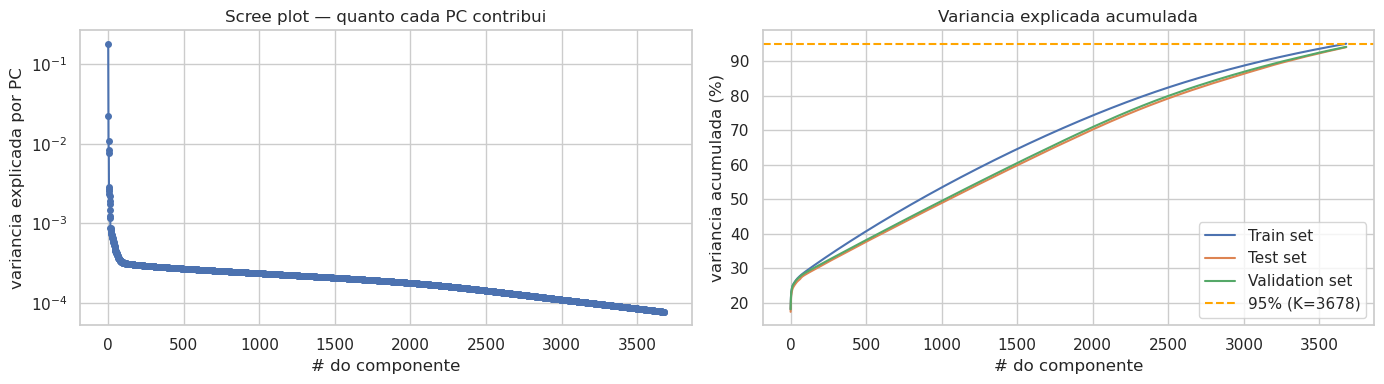

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pca_full.explained_variance_ratio_, 'o-', ms=4)
axes[0].set_xlabel('# do componente')
axes[0].set_ylabel('variancia explicada por PC')
axes[0].set_yscale('log')
axes[0].set_title('Scree plot — quanto cada PC contribui')

axes[1].plot(cumvar*100, ms=4, label = 'Train set')
axes[1].plot(test_cum_var*100, ms=4, label = 'Test set')
axes[1].plot(val_cum_var*100, ms=4, label = 'Validation set')
axes[1].axhline(95, color='orange', ls='--', label=f'95% (K={k95})')
# axes[1].axhline(99, color='red', ls='--', label=f'99% (K={k99})')
# axes[1].axvline(N_COMPONENTS, color='green', ls=':', label=f'escolhido = {N_COMPONENTS}')
axes[1].set_xlabel('# do componente')
axes[1].set_ylabel('variancia acumulada (%)')
axes[1].set_title('Variancia explicada acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

### Visualizando: os primeiros PCs

Cada PC e um "espectro virtual" — uma combinacao linear de bins de comprimento de onda. Plotando os 4 primeiros da pra ver:
- **PC1** geralmente captura o brilho geral (parece um espectro inteiro)
- **PCs intermediarios** capturam linhas e breaks
- **PCs altos** capturam ruido

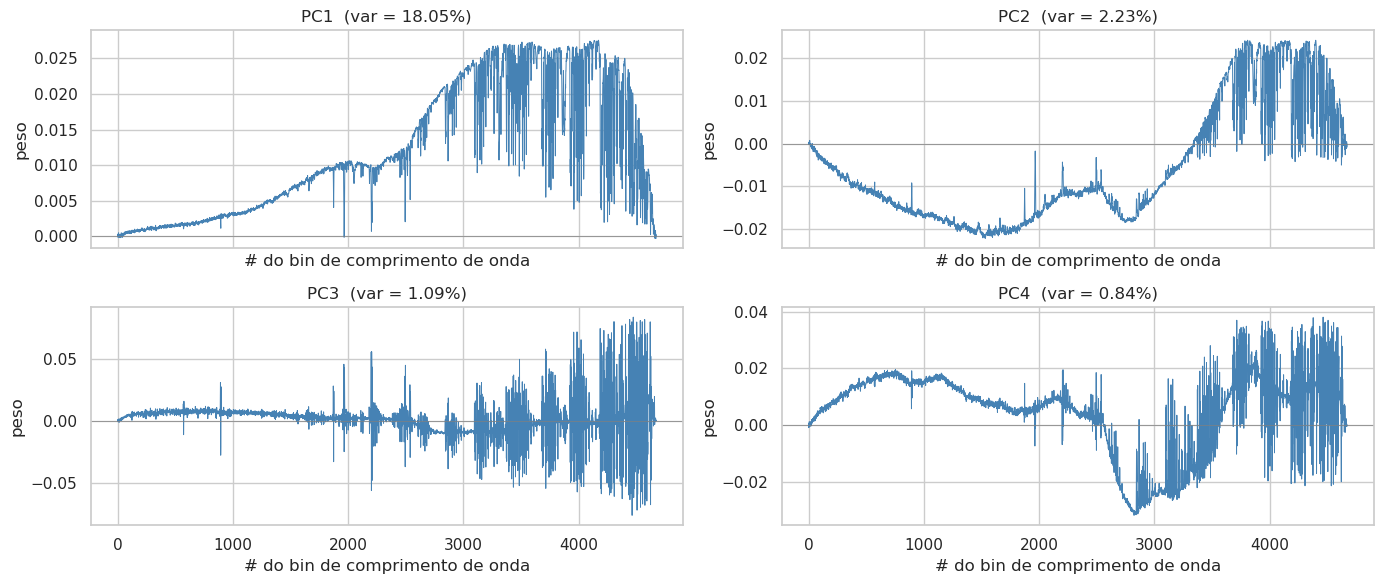

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
axes = axes.ravel()
for i in range(4):
    axes[i].plot(pca_full.components_[i], lw=0.7, color='steelblue')
    axes[i].axhline(0, color='gray', lw=0.5)
    axes[i].set_title(f'PC{i+1}  (var = {pca_full.explained_variance_ratio_[i]*100:.2f}%)')
    axes[i].set_xlabel('# do bin de comprimento de onda')
    axes[i].set_ylabel('peso')
plt.tight_layout()
plt.show()

## 6. Constroi a matriz de features final

**X = [PCs do espectro | scalars] = (N, 54)**

Os scalars **ja estao em log10**, mas os PCs estao em escalas muito diferentes (PC1 pode ter range [-50, +50], PC50 pode ter [-0.1, 0.1]). Tree-based models como XGBoost **NAO PRECISAM** de standardize (sao invariantes a escala monotonica), entao na verdade da pra usar direto.

Mas vou padronizar pra:
1. Facilitar interpretacao da feature importance (todas em escala comparavel)
2. Caso queira comparar com modelos lineares depois

In [14]:
# Concatena PCs + scalars
X_train_full = np.concatenate([P_train, S_train], axis=1)
X_val_full   = np.concatenate([P_val,   S_val  ], axis=1)
X_test_full  = np.concatenate([P_test,  S_test ], axis=1)

# Padroniza (fit so no train, anti-leak)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_full)
X_val_std   = scaler.transform(X_val_full)
X_test_std  = scaler.transform(X_test_full)

# Nomes das features (util pra feature importance)
feature_names = (
    [f'PC{i+1}' for i in range(N_COMPONENTS)]
    + ['log_max', 'log_median', 'log_sum', 'log_p95']
)

print(f'X_train_std : {X_train_std.shape}  ({N_COMPONENTS} PCs + 4 scalars = {X_train_std.shape[1]} features)')
print(f'feature_names[:5] : {feature_names[:5]}')
print(f'feature_names[-5:]: {feature_names[-5:]}')

X_train_std : (94612, 3682)  (300 PCs + 4 scalars = 3682 features)
feature_names[:5] : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
feature_names[-5:]: ['PC300', 'log_max', 'log_median', 'log_sum', 'log_p95']


## 7. XGBoost — como funciona

### Conceito

XGBoost = **muitas arvores de decisao em sequencia**, cada uma corrigindo o erro da anterior (gradient boosting).

```
predicao_final = arvore_1(x) + arvore_2(x) + arvore_3(x) + ... + arvore_N(x)
```

- arvore_1: chuta a media de y -> erro_1 = y - chute
- arvore_2: treina pra prever erro_1 -> erro_2 = erro_1 - arvore_2(x)
- arvore_3: treina pra prever erro_2
- ...

Cada arvore e "fraca" (shallow, sem overfitting individual), mas a soma de muitas vira um preditor forte.

### Hiperparametros principais

| HP | O que controla | Tipico |
|---|---|---|
| `n_estimators` | quantas arvores | 100-2000 |
| `max_depth` | profundidade max de cada arvore | 4-10 |
| `learning_rate` | peso de cada arvore (passo) | 0.01-0.3 |
| `subsample` | fracao de amostras por arvore (anti-overfit) | 0.7-1.0 |
| `colsample_bytree` | fracao de features por arvore | 0.7-1.0 |
| `reg_alpha` | L1 reg (zera features inuteis) | 0-1 |
| `reg_lambda` | L2 reg (penaliza pesos grandes) | 0-10 |

### Early stopping

Se o val_loss nao melhorar em K rodadas, para de adicionar arvores. Equivalente ao EarlyStopping do Keras. **MUITO importante pra evitar overfit no XGBoost** — sem isso, com muitas arvores ele decora o train.

### Por que objetivo MSE (`reg:squarederror`)?

Usamos a mesma loss do baseline `xgb_lrg.ipynb` pra comparacao justa entre os dois modelos. MSE penaliza erros grandes de forma quadratica, o que tende a empurrar o `sigma_NMAD` pra baixo (modelo evita "errar muito" em alguns casos). MAE (`reg:absoluteerror`) seria uma alternativa mais robusta a outliers — vale testar depois se ainda houver galaxias com z mal medido no catalogo.

In [15]:
# ============================================================
# XGBoost com HPs sensatos (sem otimizacao — esse e o baseline)
# ============================================================
model = xgb.XGBRegressor(
    # tamanho do modelo
    n_estimators=10000,        # max de arvores (mas early stopping vai cortar muito antes)
    max_depth=6,              # 6 = profundidade moderada
    learning_rate=0.05,       # passo pequeno = mais arvores, mas modelo mais estavel
    
    # regularizacao
    subsample=0.8,            # cada arvore ve 80% das amostras
    colsample_bytree=0.8,     # cada arvore ve 80% das features
    reg_alpha=0.1,            # L1 leve
    reg_lambda=1.0,           # L2 padrao
    min_child_weight=3,       # nao splita se subarvore tem < 3 amostras (anti-overfit)
    
    # outros
    objective='reg:squarederror',    # MSE (mesma loss do xgb_lrg baseline; comparacao direta)
    tree_method='hist',              # rapido em CPU, equivalente a LightGBM
    random_state=SEED,
    n_jobs=-1,                       # usa todos os CPUs
    early_stopping_rounds=50,        # para se val_rmse nao melhorar em 50 rodadas
)

print('HPs do modelo:')
for k, v in model.get_params().items():
    if v is not None and k not in ('callbacks', 'feature_types', 'missing'):
        print(f'  {k:30} = {v}')

HPs do modelo:
  objective                      = reg:squarederror
  colsample_bytree               = 0.8
  early_stopping_rounds          = 50
  enable_categorical             = False
  learning_rate                  = 0.05
  max_depth                      = 6
  min_child_weight               = 3
  n_estimators                   = 10000
  n_jobs                         = -1
  random_state                   = 42
  reg_alpha                      = 0.1
  reg_lambda                     = 1.0
  subsample                      = 0.8
  tree_method                    = hist


In [16]:
# ============================================================
# TREINO
# ============================================================
# eval_set=[(val, y_val)] -> XGBoost reporta o val_mae a cada rodada
# verbose=False pra nao poluir o log; mostro o resumo depois

t0 = time.time()
model.fit(
    X_train_std, y_train,
    eval_set=[(X_train_std, y_train), (X_val_std, y_val)],
    verbose=False,
)
train_time = time.time() - t0

best_iter = model.best_iteration
print(f'Tempo de treino : {train_time:.1f}s')
print(f'Melhor iteracao : {best_iter}  (early stopping pegou aqui)')
print(f'Total de arvores: {model.n_estimators}  (max), {best_iter+1} usadas no modelo final')

KeyboardInterrupt: 

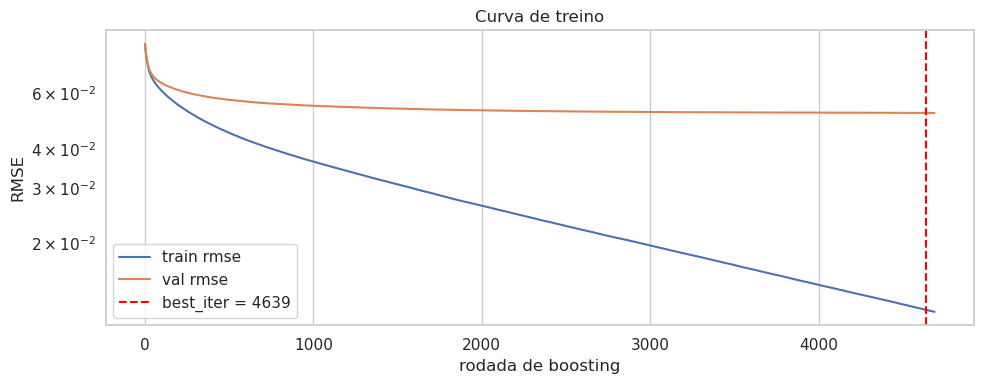

In [14]:
# ============================================================
# CURVA DE TREINO — train vs val (loss = RMSE por causa do objective MSE)
# ============================================================
# Esperado: train cai sempre. val cai e depois estabiliza/sobe (overfit).
# Onde val para de melhorar = melhor numero de arvores (e onde paramos).

results = model.evals_result()
metric_name = list(results['validation_0'].keys())[0]   # 'rmse' (objective=MSE) ou 'mae'
train_loss = results['validation_0'][metric_name]
val_loss   = results['validation_1'][metric_name]

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label=f'train {metric_name}', lw=1.5)
plt.plot(val_loss,   label=f'val {metric_name}',   lw=1.5)
plt.axvline(best_iter, color='red', ls='--', label=f'best_iter = {best_iter}')
plt.xlabel('rodada de boosting')
plt.ylabel(metric_name.upper())
plt.title('Curva de treino')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Avaliacao no test

Mesmas metricas que a CNN usa pra comparacao direta.

In [15]:
def delta_z_norm(z_pred, z_true):
    return (z_pred - z_true) / (1.0 + z_true)

def bias(dz):
    return float(np.median(dz))

def sigma_NMAD(dz):
    return float(1.4826 * np.median(np.abs(dz - np.median(dz))))

def eta_outliers(dz, thr=0.15):
    return float(100.0 * np.mean(np.abs(dz) > thr))


y_pred_test = model.predict(X_test_std)
dz_test = delta_z_norm(y_pred_test, y_test)

test_metrics = {
    'mae':               float(np.mean(np.abs(y_pred_test - y_test))),
    'bias':              bias(dz_test),
    'sigma_nmad':        sigma_NMAD(dz_test),
    'eta_outliers_0.05': eta_outliers(dz_test, 0.05),
    'eta_outliers_0.15': eta_outliers(dz_test, 0.15),
}

print('=' * 60)
print(f'RESULTADO NO TEST  (n = {len(y_test):,}, objeto = {OBJECT_TYPE})')
print('=' * 60)
for k, v in test_metrics.items():
    print(f'  {k:>22} = {v:.4f}')

RESULTADO NO TEST  (n = 19,643, objeto = LRG)
                     mae = 0.0411
                    bias = 0.0021
              sigma_nmad = 0.0286
       eta_outliers_0.05 = 9.3723
       eta_outliers_0.15 = 0.0051


## 9. Feature importance — quais PCs e scalars o XGBoost usa?

Tres tipos de importance no XGBoost:

- **gain**: ganho medio em loss que essa feature da quando usada num split. Mais util.
- **cover**: numero medio de amostras impactadas
- **frequency**: quantas vezes a feature foi usada num split

Vou usar `gain` (default).

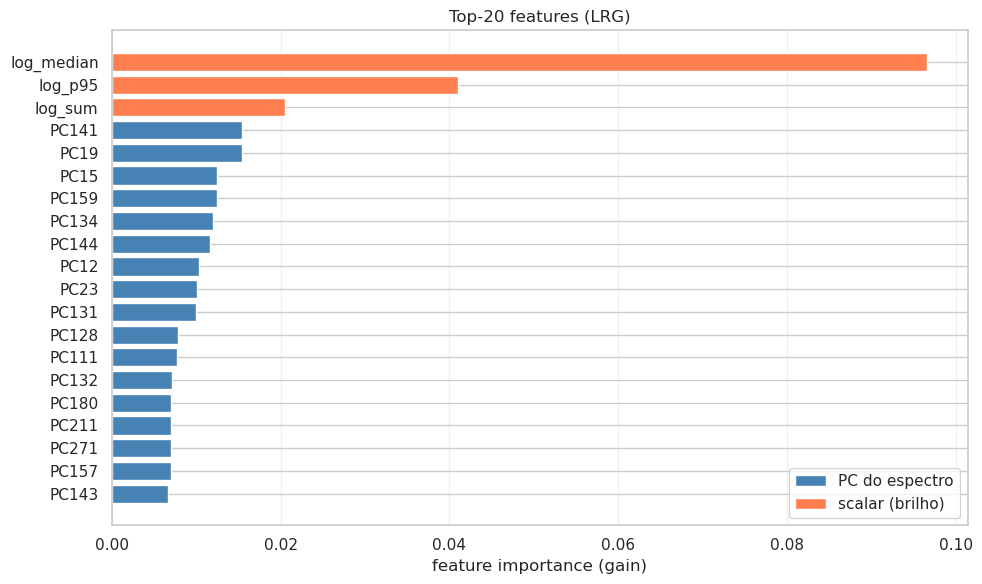


Importance total dos scalars : 16.0%
Importance total dos PCs     : 84.0%


In [16]:
# importance_type='gain' e o default em xgb.XGBRegressor
importances = pd.Series(
    model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

# Plot top-20
fig, ax = plt.subplots(figsize=(10, 6))
top = importances.head(20)
colors = ['coral' if 'PC' not in name else 'steelblue' for name in top.index]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.set_xlabel('feature importance (gain)')
ax.set_title(f'Top-20 features ({OBJECT_TYPE})')
ax.grid(axis='x', alpha=0.3)

# legenda inline
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', label='PC do espectro'),
    Patch(facecolor='coral', label='scalar (brilho)'),
])
plt.tight_layout()
plt.show()

# Soma de importance: scalars vs PCs
scalars_total = importances[['log_max', 'log_median', 'log_sum', 'log_p95']].sum()
pcs_total = importances.drop(['log_max', 'log_median', 'log_sum', 'log_p95']).sum()
print(f'\nImportance total dos scalars : {scalars_total*100:.1f}%')
print(f'Importance total dos PCs     : {pcs_total*100:.1f}%')

## 10. Plots do modelo final

Mesmos plots da CNN pra comparacao direta:
- (a) z_pred vs z_real
- (b) histograma de delta_z
- (c) residuos vs z_real

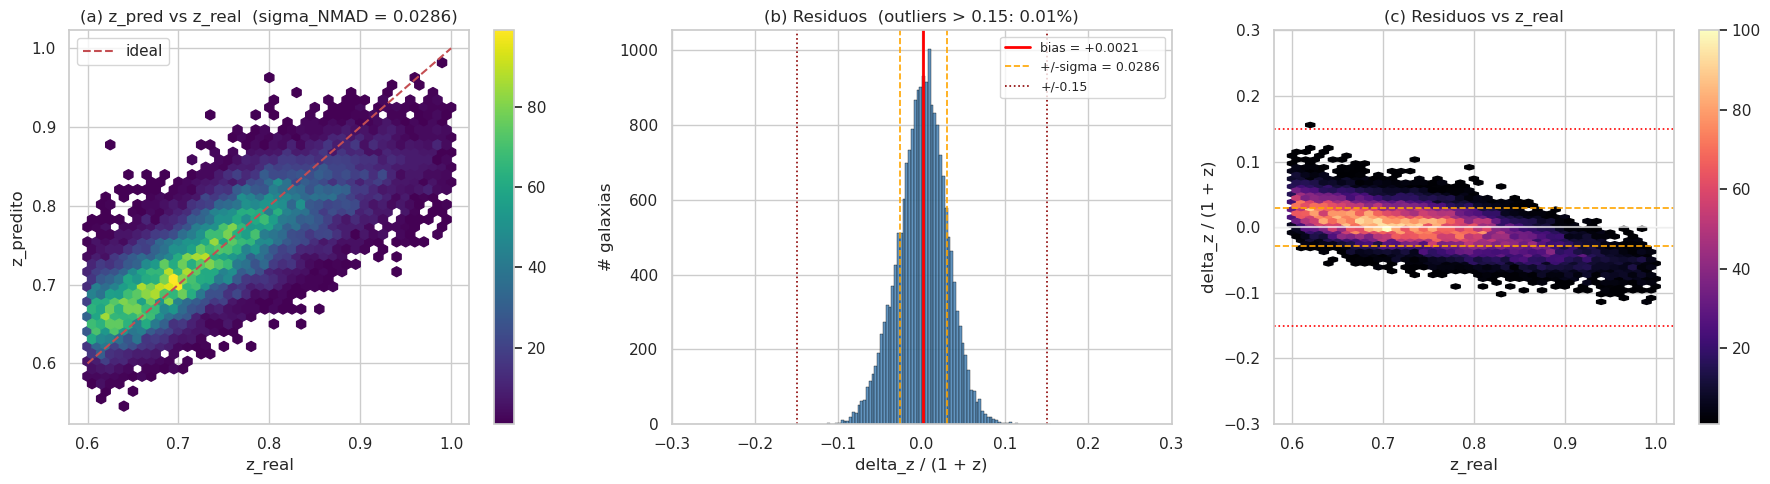

In [17]:
bias_test = test_metrics['bias']
sigma_test = test_metrics['sigma_nmad']
eta_test = test_metrics['eta_outliers_0.15']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) z_pred vs z_real
hb = axes[0].hexbin(y_test, y_pred_test, gridsize=40, cmap='viridis', mincnt=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5, label='ideal')
axes[0].set_xlabel('z_real'); axes[0].set_ylabel('z_predito')
axes[0].set_title(f'(a) z_pred vs z_real  (sigma_NMAD = {sigma_test:.4f})')
axes[0].legend(); plt.colorbar(hb, ax=axes[0])

# (b) hist delta_z
axes[1].hist(np.clip(dz_test, -0.3, 0.3), bins=80, color='steelblue', alpha=0.85, edgecolor='black', lw=0.3)
axes[1].axvline(bias_test, color='red', lw=2, label=f'bias = {bias_test:+.4f}')
axes[1].axvline(bias_test + sigma_test, color='orange', lw=1.2, ls='--', label=f'+/-sigma = {sigma_test:.4f}')
axes[1].axvline(bias_test - sigma_test, color='orange', lw=1.2, ls='--')
axes[1].axvline(+0.15, color='darkred', lw=1.2, ls=':', label='+/-0.15')
axes[1].axvline(-0.15, color='darkred', lw=1.2, ls=':')
axes[1].set_xlabel('delta_z / (1 + z)'); axes[1].set_ylabel('# galaxias')
axes[1].set_title(f'(b) Residuos  (outliers > 0.15: {eta_test:.2f}%)')
axes[1].legend(fontsize=9); axes[1].set_xlim(-0.3, 0.3)

# (c) residuos vs z_real
hb2 = axes[2].hexbin(y_test, np.clip(dz_test, -0.3, 0.3), gridsize=40, cmap='magma', mincnt=1)
axes[2].axhline(0, color='white', lw=1.5, alpha=0.7)
axes[2].axhline(+sigma_test, color='orange', lw=1.2, ls='--')
axes[2].axhline(-sigma_test, color='orange', lw=1.2, ls='--')
axes[2].axhline(+0.15, color='red', lw=1.2, ls=':')
axes[2].axhline(-0.15, color='red', lw=1.2, ls=':')
axes[2].set_xlabel('z_real'); axes[2].set_ylabel('delta_z / (1 + z)')
axes[2].set_title('(c) Residuos vs z_real'); axes[2].set_ylim(-0.3, 0.3)
plt.colorbar(hb2, ax=axes[2])

plt.tight_layout()
plt.show()

## 12. Salvar

Modelo + spec_scaler + PCA + scaler + predicoes + metadata + metricas-por-bin.

Pipeline de inferencia em galaxias novas (agora tem **2 scalers**):
1. Carrega o modelo `.json`, `spec_scaler.pkl`, `pca.pkl`, `scaler.pkl`
2. Calcula scalars com `extract_scalars` (no fluxo bruto)
3. `spec_scaler.transform(x_bruto)` -> espectro padronizado por bin
4. `pca.transform(x_std)` -> PCs
5. Concat com scalars -> `scaler.transform(...)` -> input do XGBoost
6. `model.predict(x)`

In [ ]:
import joblib

# Diretorios — pasta SEPARADA do didatico (xgb_pca_stdscaler/), sem sobrescrever
RUN_TAG = f'xgb_pca_stdscaler-{OBJECT_TYPE}-pc{N_COMPONENTS}_s{SEED}'
RUN_DIR = RESULTS_DIR / OBJECT_TYPE / 'xgb_pca_stdscaler' / RUN_TAG
MODEL_DIR = MODELS_DIR / OBJECT_TYPE / 'xgb_pca_stdscaler' / RUN_TAG
for d in (RUN_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Salva tudo (DOIS scalers agora: spec_scaler no espectro + scaler final em PCs+scalars)
model.save_model(MODEL_DIR / 'xgb_model.json')
joblib.dump(spec_scaler, MODEL_DIR / 'spec_scaler.pkl')  # column-wise no espectro bruto
joblib.dump(pca,         MODEL_DIR / 'pca.pkl')
joblib.dump(scaler,      MODEL_DIR / 'scaler.pkl')        # final em PCs+scalars

np.savez(
    RUN_DIR / 'test_outputs.npz',
    y_test=y_test, y_pred=y_pred_test, delta_z=dz_test,
)

np.savez(
    RUN_DIR / 'split_idx.npz',
    pool_idx=pool_idx, test_idx=test_idx,
    train_in_pool=train_in_pool, val_in_pool=val_in_pool,
)

importances.to_csv(RUN_DIR / 'feature_importance.csv', header=['importance_gain'])
bin_df.to_csv(RUN_DIR / 'metrics_by_zbin.csv', index=False)

run_info = {
    'created_utc': datetime.now(timezone.utc).isoformat().replace('+00:00', 'Z'),
    'run_tag': RUN_TAG,
    'object_type': OBJECT_TYPE,
    'seed': SEED,
    'normalization': 'StandardScaler (column-wise, fit on train)',
    'n_components_pca': N_COMPONENTS,
    'pca_variance_retained': float(pca.explained_variance_ratio_.sum()),
    'feature_names': feature_names,
    'splits': {
        'n_train': int(len(y_train)),
        'n_val': int(len(y_val)),
        'n_test': int(len(y_test)),
    },
    'xgb_params': {k: v for k, v in model.get_params().items() if v is not None},
    'best_iteration': int(best_iter),
    'test_metrics': test_metrics,
    'train_time_s': float(train_time),
}
with open(RUN_DIR / 'run_info.json', 'w') as f:
    json.dump(run_info, f, indent=2, default=str)

print(f'Salvo em:')
print(f'  modelo + spec_scaler + PCA + scaler : {MODEL_DIR}/')
print(f'  predicoes + importance + bins       : {RUN_DIR}/')

## 13. Conclusao + proximos passos

Este notebook serve como **baseline didatico de XGBoost** pra spec-z. O proximo passo natural e:

1. **Otimizar HPs com Optuna**: ver `xgb_optuna_*.ipynb`
2. **Comparar com a CNN**: as metricas do `run_info.json` casam com as do notebook 07? Pra overlay visual no TCC: gera no notebook da CNN os mesmos 4 paineis da secao 11 (com `y_test_cnn` e `y_pred_cnn`) e empilha lado a lado.
3. **Experimentar mais features**: catalogos fotometricos (mags + cores) podem ajudar muito em z baixo onde o espectro nao tem muita variacao
4. **Stacking**: usar predicao da CNN como feature do XGBoost (modelo hibrido)

### Comparacao tipica esperada (LRG)

| Modelo | sigma_NMAD esperado | tempo |
|---|---|---|
| XGBoost PCA+scalars (este nb, 300 PCs) | ~0.018-0.025 | ~5-10 min |
| CNN single-input (nb 07) | ~0.003-0.007 | horas |
| XGBoost otimizado (nb 05) | ~0.015-0.020 | dezenas de minutos |

In [22]:
import joblib

# Diretorios
RUN_TAG = f'xgb_pca_didatico-{OBJECT_TYPE}-pc{N_COMPONENTS}_s{SEED}'
RUN_DIR = RESULTS_DIR / OBJECT_TYPE / 'xgb_pca_didatico' / RUN_TAG
MODEL_DIR = MODELS_DIR / OBJECT_TYPE / 'xgb_pca_didatico' / RUN_TAG
for d in (RUN_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Salva tudo
model.save_model(MODEL_DIR / 'xgb_model.json')
joblib.dump(pca,     MODEL_DIR / 'pca.pkl')
joblib.dump(scaler,  MODEL_DIR / 'scaler.pkl')

np.savez(
    RUN_DIR / 'test_outputs.npz',
    y_test=y_test, y_pred=y_pred_test, delta_z=dz_test,
)

np.savez(
    RUN_DIR / 'split_idx.npz',
    pool_idx=pool_idx, test_idx=test_idx,
    train_in_pool=train_in_pool, val_in_pool=val_in_pool,
)

importances.to_csv(RUN_DIR / 'feature_importance.csv', header=['importance_gain'])

run_info = {
    'created_utc': datetime.now(timezone.utc).isoformat().replace('+00:00', 'Z'),
    'run_tag': RUN_TAG,
    'object_type': OBJECT_TYPE,
    'seed': SEED,
    'n_components_pca': N_COMPONENTS,
    'pca_variance_retained': float(pca.explained_variance_ratio_.sum()),
    'feature_names': feature_names,
    'splits': {
        'n_train': int(len(y_train)),
        'n_val': int(len(y_val)),
        'n_test': int(len(y_test)),
    },
    'xgb_params': {k: v for k, v in model.get_params().items() if v is not None},
    'best_iteration': int(best_iter),
    'test_metrics': test_metrics,
    'train_time_s': float(train_time),
}
with open(RUN_DIR / 'run_info.json', 'w') as f:
    json.dump(run_info, f, indent=2, default=str)

print(f'Salvo em:')
print(f'  modelo + PCA + scaler : {MODEL_DIR}/')
print(f'  predicoes + importance: {RUN_DIR}/')

Salvo em:
  modelo + PCA + scaler : /home/thalita/spec_z_ml/models/LRG/xgb_pca_didatico/xgb_pca_didatico-LRG-pc50_s42/
  predicoes + importance: /home/thalita/spec_z_ml/results/LRG/xgb_pca_didatico/xgb_pca_didatico-LRG-pc50_s42/


## 12. Conclusao + proximos passos

Este notebook serve como **baseline didatico de XGBoost** pra spec-z. O proximo passo natural e:

1. **Otimizar HPs com Optuna**: ver `xgb_optuna_*.ipynb`
2. **Comparar com a CNN**: as metricas do `run_info.json` casam com as do notebook 07?
3. **Experimentar mais features**: catalogos fotometricos (mags + cores) podem ajudar muito em z baixo onde o espectro nao tem muita variacao
4. **Stacking**: usar predicao da CNN como feature do XGBoost (modelo hibrido)

### Comparacao tipica esperada (LRG)

| Modelo | sigma_NMAD esperado | tempo |
|---|---|---|
| XGBoost PCA+scalars (este nb) | ~0.005-0.010 | poucos minutos |
| CNN single-input (nb 07) | ~0.003-0.007 | horas |
| XGBoost otimizado (nb 05) | ~0.004-0.008 | dezenas de minutos |